In [14]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [15]:
from google.colab import files
uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean (1).json


In [16]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')

print(df.shape)

df.head()

(500, 12)


,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


# **TF-IDF**

In [18]:
df["full_text"] = (
    df["clean_Titre"].astype(str)
    + " "
    + df["clean_commentaire"].astype(str)
)

In [19]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["full_text"]
)

In [20]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(
    df["satisfaction"]
)


# **TRAIN / TEST SPLIT**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# **XGBOOST BASELINE**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)



xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)


#cross validation
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

# Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_weighted'
)

print("Cross Validation F1 Scores :")
print(cv_scores)

print()

print(
    "Mean CV F1-score :",
    cv_scores.mean()
)
xgb.fit(
    X_train,
    y_train
)



y_pred_xgb = xgb.predict(
    X_test
)



print("===== XGBOOST =====\n")

print(
    "Accuracy :",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)



print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Cross Validation F1 Scores :
[0.68236886 0.61058712 0.5546707  0.56632618 0.5599047 ]

Mean CV F1-score : 0.5947715124266043
===== XGBOOST =====

Accuracy : 0.58
              precision    recall  f1-score   support

    negative       0.64      0.73      0.68        37
     neutral       0.20      0.14      0.17        21
    positive       0.65      0.67      0.66        42

    accuracy                           0.58       100
   macro avg       0.50      0.51      0.50       100
weighted avg       0.55      0.58      0.56       100



# **HYPERPARAMETER TUNING**

In [30]:
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [4, 6, 8],

    'learning_rate': [0.05, 0.1],

    'subsample': [0.8, 1.0],

    'colsample_bytree': [0.8, 1.0]
}

In [31]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(

    estimator=xgb,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=cv,

    verbose=1,

    n_jobs=-1
)

In [32]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_delta_step=None, max_depth=6,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=200,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1_weighted', verbose=1)

In [33]:
print(
    "Best Parameters :"
)

print(
    grid_search.best_params_
)

Best Parameters :
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}


In [34]:
print(
    "Best CV Score :",
    grid_search.best_score_
)

Best CV Score : 0.5990974081740978


# **Matrice de confusion**

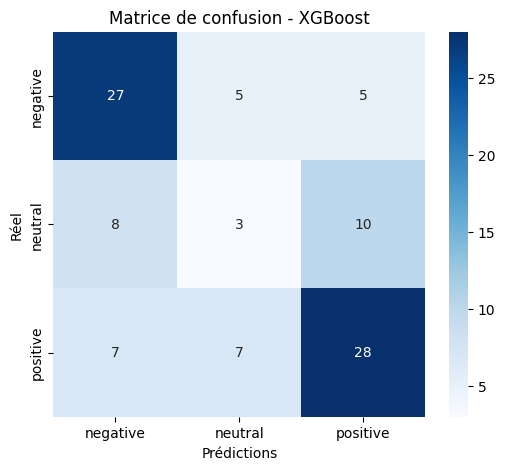

In [23]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - XGBoost')

plt.show()


# **XGboost +class weight**


In [24]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred_xgb_weighted = xgb_weighted.predict(X_test)

print("===== XGBOOST + CLASS WEIGHT =====")

print(
    classification_report(
        y_test,
        y_pred_xgb_weighted,
        target_names=label_encoder.classes_
    )
)

===== XGBOOST + CLASS WEIGHT =====
              precision    recall  f1-score   support

    negative       0.68      0.73      0.70        37
     neutral       0.33      0.29      0.31        21
    positive       0.67      0.67      0.67        42

    accuracy                           0.61       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.60      0.61      0.60       100



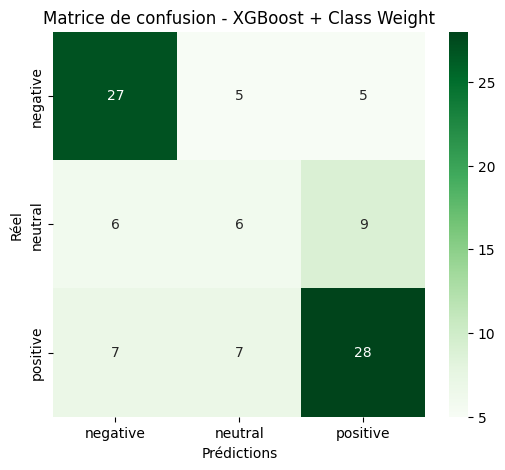

In [25]:
cm_weighted = confusion_matrix(
    y_test,
    y_pred_xgb_weighted
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - XGBoost + Class Weight')

plt.show()


# **xgboost + SMOTE**

In [26]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)

print("===== XGBOOST + SMOTE =====")

print(
    classification_report(
        y_test,
        y_pred_xgb_smote,
        target_names=label_encoder.classes_
    )
)

===== XGBOOST + SMOTE =====
              precision    recall  f1-score   support

    negative       0.67      0.76      0.71        37
     neutral       0.31      0.24      0.27        21
    positive       0.67      0.67      0.67        42

    accuracy                           0.61       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.59      0.61      0.60       100



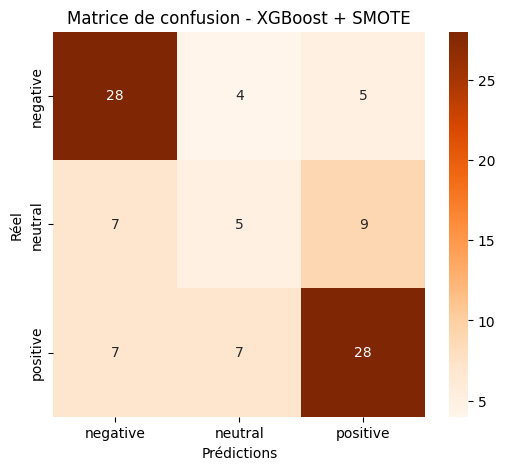

In [27]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_xgb_smote
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - XGBoost + SMOTE')

plt.show()


# **TABLEAU COMPARATIF**

In [28]:
results_xgb = pd.DataFrame({

    'Model': [
        'XGBoost',
        'XGBoost + Class Weight',
        'XGBoost + SMOTE'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_weighted),
        accuracy_score(y_test, y_pred_xgb_smote)
    ],

    'Precision': [
        precision_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        )
    ],

    'F1-score': [
        f1_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        )
    ]
})

print(results_xgb)


                    Model  Accuracy  Precision  Recall  F1-score
0                 XGBoost      0.58   0.553346    0.58  0.564617
1  XGBoost + Class Weight      0.61   0.599750    0.61  0.604096
2         XGBoost + SMOTE      0.61   0.592292    0.61  0.599035


# **Modèle apres tunning des hyperparmetres**

In [35]:
best_xgb = grid_search.best_estimator_

In [36]:
y_pred = best_xgb.predict(
    X_test
)

In [37]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.67      0.70      0.68        37
     neutral       0.27      0.19      0.22        21
    positive       0.65      0.71      0.68        42

    accuracy                           0.60       100
   macro avg       0.53      0.54      0.53       100
weighted avg       0.58      0.60      0.59       100



# **Comparaison Finale**

In [38]:
results_xgb = pd.DataFrame({

    'Model': [
        'XGBoost',
        'XGBoost + Class Weight',
        'XGBoost + SMOTE',
        'XGBoost + Hyperparameter Tuning'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_xgb),

        accuracy_score(
            y_test,
            y_pred_xgb_weighted
        ),

        accuracy_score(
            y_test,
            y_pred_xgb_smote
        ),

        accuracy_score(
            y_test,
            y_pred
        )
    ],

    'Precision': [

        precision_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred,
            average='weighted'
        )
    ],

    'Recall': [

        recall_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred,
            average='weighted'
        )
    ],

    'F1-score': [

        f1_score(
            y_test,
            y_pred_xgb,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_xgb_weighted,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_xgb_smote,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred,
            average='weighted'
        )
    ]
})

print(results_xgb)

                             Model  Accuracy  Precision  Recall  F1-score
0                          XGBoost      0.58   0.553346    0.58  0.564617
1           XGBoost + Class Weight      0.61   0.599750    0.61  0.604096
2                  XGBoost + SMOTE      0.61   0.592292    0.61  0.599035
3  XGBoost + Hyperparameter Tuning      0.60   0.576580    0.60  0.586188


le problème ne vient plus vraiment des hyperparamètres.

Le vrai problème est :

dataset petit (~500 avis)
classe neutral ambiguë
TF-IDF limité sémantiquement